In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Note to self: I'll use index_col=0 because the first column contains the labels (Mercury, Venus, etc.)
df_kepler = pd.read_csv('solar_system.csv', index_col=0)

df_kepler

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
Attribute,,,,,,,,,,
Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8


In [3]:
# Shape of the dataset (rows, columns)
shape = df_kepler.shape
print(f"Shape of the dataset: {shape}")

#Number of rows and columns specifically
print(f"Number of rows: {len(df_kepler)}") 
print(f"Number of columns: {len(df_kepler.columns)}") 

#First and last five rows
print("\nFirst five rows:")
print(df_kepler.head(5)) 
print("\nLast five rows:")
print(df_kepler.tail(5)) 

# Column and row names
print("\nColumn names:")
print(df_kepler.columns.tolist()) 
print("\nRow names:")
print(df_kepler.index.tolist()) 

Shape of the dataset: (20, 10)
Number of rows: 20
Number of columns: 10

First five rows:
                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97  0.073  0.642    1898     568   
Diameter (km)             4879  12104  12756   3475   6792  142984  120536   
Density (kg/m^3)          5429   5243   5514   3340   3934    1326     687   
Gravity (m/s^2)            3.7    8.9    9.8    1.6    3.7    23.1     9.0   
Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

                       Uranus Neptune   Pluto  
Attribute                                      
Mass (10^24kg)           86.8     102  0.0130  
Diameter (km)           51118   49528    2376  
Density (kg/m^3)         1270    1638    1850  
Gravity (m/s^2)           8.7    11.0     0.7  
Escape Velocity (km/s)   21.3    23.5     1.3  

Last five rows:
          

Sorry I'm not sure if I'm supposed to answer the questions above by code or by a markdown cell (aside from the print statements)? All answers are above!

In [12]:
# Extracting rows as variables and converting to floats
orbital_period = df_kepler.loc['Orbital Period (days)'].astype(float)
perihelion = df_kepler.loc['Perihelion (10^6 km)'].astype(float)
aphelion = df_kepler.loc['Aphelion (10^6 km)'].astype(float)

print("Orbital Period (first 3):")
print(orbital_period.head(3))

Orbital Period (first 3):
Mercury     88.0
Venus      224.7
Earth      365.2
Name: Orbital Period (days), dtype: float64


Perihelion: The closest point to the Sun in a planet's orbit.
Aphelion: The farthest point from the Sun in a planet's orbit.
Semi-major axis: Half of the longest diameter of the elliptical orbit, which acts as the average distance from the Sun.

In [13]:
#Computing the semi-major axis
semi_major_axis = (perihelion + aphelion) / 2

#Adding this new data as a row in da DataFrame
df_kepler.loc['Semi-major axis (10^6 km)'] = semi_major_axis

# Printing new shape
print(f"New Shape: {df_kepler.shape}")

#This is just a peek
print(df_kepler.loc[['Semi-major axis (10^6 km)']])

New Shape: (21, 10)
                          Mercury  Venus  Earth    Moon   Mars Jupiter  \
Attribute                                                                
Semi-major axis (10^6 km)    57.9  108.2  149.6  0.3845  228.0   778.5   

                            Saturn   Uranus Neptune    Pluto  
Attribute                                                     
Semi-major axis (10^6 km)  1432.05  2867.05  4515.0  5906.35  


In [14]:
def kepler_model(a, m):
    return m * (a**1.5)

x_data = semi_major_axis.values
y_data = orbital_period.values

# popt contains the best fit value for m
popt, pcov = curve_fit(kepler_model, x_data, y_data)
m_best = popt[0]

print(f"The best fit value for m is: {m_best:.6f}")

The best fit value for m is: 0.198800


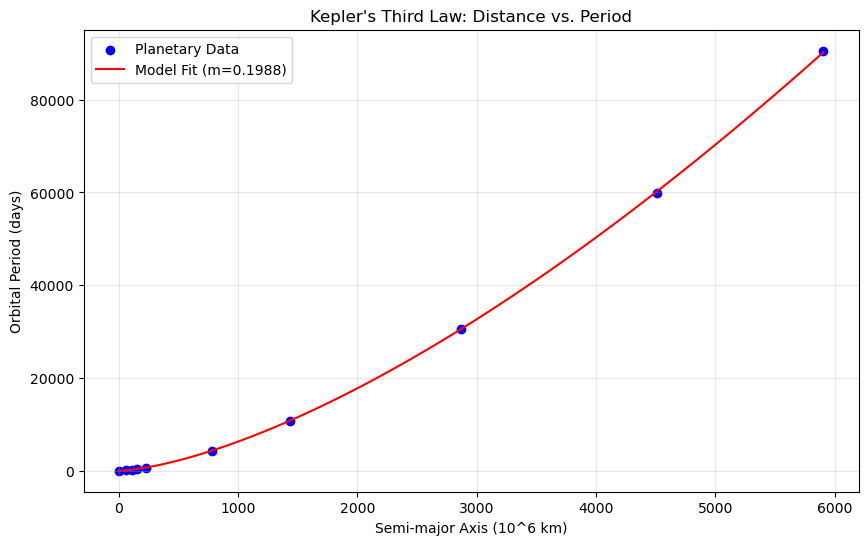

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(x_data, y_data, color='blue', label='Planetary Data')

x_line = np.linspace(min(x_data), max(x_data), 100)
y_line = kepler_model(x_line, m_best)
plt.plot(x_line, y_line, color='red', label=f'Model Fit (m={m_best:.4f})')

plt.title("Kepler's Third Law: Distance vs. Period")
plt.xlabel("Semi-major Axis (10^6 km)")
plt.ylabel("Orbital Period (days)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Sorry for this unecessary block, but this graph looks so GOOD! Wow!!!!!!

In [16]:
df_kepler.to_csv("kepler.csv")
print("Saved kepler.csv successfully!")

Saved kepler.csv successfully!
